In [2]:
import numpy as np
import pandas as pd
import os   
import matplotlib.pyplot as plt

import lightgbm as lgbm
from lightgbm import Booster
#import structureboost as stb
import ml_insights as mli
from sklearn.metrics import log_loss
pd.set_option('display.max_columns',1000)
pd.set_option('display.max_rows',1000)

from aggregateDataFunctions import groupsOf3Aggregate, groupOf9Aggregate

mainDf = pd.read_csv('CombinedWithWinDashesNaN.csv')
oddsDf = pd.read_csv('DashesChangedOddsDataTest.csv')
aggregateData = groupOf9Aggregate


In [3]:
mainDf = aggregateData(mainDf)

trainX = mainDf.iloc[:13000,:]
validX = mainDf.iloc[13000:14500,:]
testX = mainDf.iloc[14500:,:]

trainY = trainX['home_win'].to_numpy()
validY = validX['home_win'].to_numpy()
testY = testX['home_win'].to_numpy()

trainX = trainX.drop("home_win", axis='columns')
validX = validX.drop("home_win", axis='columns')
testX = testX.drop("home_win", axis='columns')

c:\Users\nhleo\Downloads\MLB-Moneyline\aggregateDataFunctions.py:146: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[mean_col_name] = group_mean
c:\Users\nhleo\Downloads\MLB-Moneyline\aggregateDataFunctions.py:147: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[std_col_name]  = group_std
c:\Users\nhleo\Downloads\MLB-Moneyline\aggregateDataFunctions.py:146: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

In [4]:
saveModel = True
modelSaveName = 'test.txt'

model_save_name = os.path.join("models", modelSaveName)

lgbm1 = lgbm.LGBMClassifier(n_estimators=1000, learning_rate=.02, max_depth=2)
lgbm1.fit(trainX, trainY, eval_set=(validX, validY), eval_metric='logloss', 
          callbacks=[lgbm.early_stopping(stopping_rounds=50), lgbm.log_evaluation(10)])
if saveModel:
    lgbm1.booster_.save_model(model_save_name)

[LightGBM] [Info] Number of positive: 6951, number of negative: 6049
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 73601
[LightGBM] [Info] Number of data points in the train set: 13000, number of used features: 321
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.534692 -> initscore=0.138993
[LightGBM] [Info] Start training from score 0.138993
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [ ]:
hv_mean = mainDf['home_win'].sum() / 16074
testX = testX.astype(float)
preds_lgbm = lgbm1.predict_proba(testX)[:,1]
oddsDf['win_odds'] = np.where(
    oddsDf['home_win'] == 1,
    oddsDf['homeDec'],
    oddsDf['awayDec']
)
preds_weighted = 1 * preds_lgbm + 0 * oddsDf['combinedOdds']
log_loss(testY, preds_weighted), log_loss(testY, oddsDf.win_odds), log_loss(testY, hv_mean*np.ones(len(testY)))

(0.6354336318246105, 0.6528598482231269, 0.6925878945236387)

In [6]:
ll_test = log_loss(testY, preds_lgbm)
preds_lgbm_test = lgbm1.predict_proba(testX)[:,1]
sv_lgbm = lgbm1.predict(testX, pred_contrib=True)
sv_lgbm = pd.DataFrame(sv_lgbm)
sv_lgbm.columns = list(testX.columns)+['Intercept']
sv_vec = sv_lgbm.abs().mean().sort_values(ascending=False)
print('\nAvg Shap Vals')
print(sv_vec)   



Avg Shap Vals
woba_pitch_away                              0.209207
woba_pitch_home                              0.175873
Intercept                                    0.154859
woba_home_all_mean                           0.118071
woba_bullpen_away                            0.073391
slg_pitch_away                               0.066345
slg_away_all_mean                            0.055038
woba_away_all_mean                           0.050092
obp_pitch_home                               0.044188
woba_bullpen_home                            0.042750
slg_pitch_home                               0.040361
xslg_away_all_mean                           0.038834
iso_pitch_home                               0.037832
total_vs_hand_away_all_mean                  0.032905
iso_bullpen_away                             0.030201
woba_vs_hand_home_all_mean                   0.029790
xwoba_vs_hand_home_all_mean                  0.029097
ba_pitch_away                                0.028082
iso_pitch_awa

(array([  0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          5.,   4.,   6.,   8.,  15.,   9.,  24.,  28.,  32.,  27.,  37.,
         57.,  44.,  52.,  55.,  82.,  80.,  62.,  77.,  78., 123.,  75.,
         83.,  90.,  76.,  87.,  57.,  53.,  35.,  28.,  26.,  17.,  14.,
         11.,   6.,   2.,   2.,   2.,   2.,   0.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.]),
 array([-0.6 , -0.58, -0.56, -0.54, -0.52, -0.5 , -0.48, -0.46, -0.44,
        -0.42, -0.4 , -0.38, -0.36, -0.34, -0.32, -0.3 , -0.28, -0.26,
        -0.24, -0.22, -0.2 , -0.18, -0.16, -0.14, -0.12, -0.1 , -0.08,
        -0.06, -0.04, -0.02,  0.  ,  0.02,  0.04,  0.06,  0.08,  0.1 ,
         0.12,  0.14,  0.16,  0.18,  0.2 ,  0.22,  0.24,  0.26,  0.28,
         0.3 ,  0.32,  0.34,  0.36,  0.38,  0.4 ,  0.42,  0.44,  0.46,
         0.48,  0.5 ,  0.52,  0.54,  0.56,  0.58,  0.6 ]),
 <BarContainer object of 60 artists>)

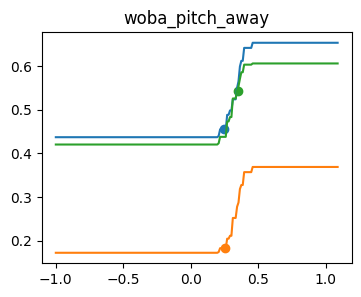

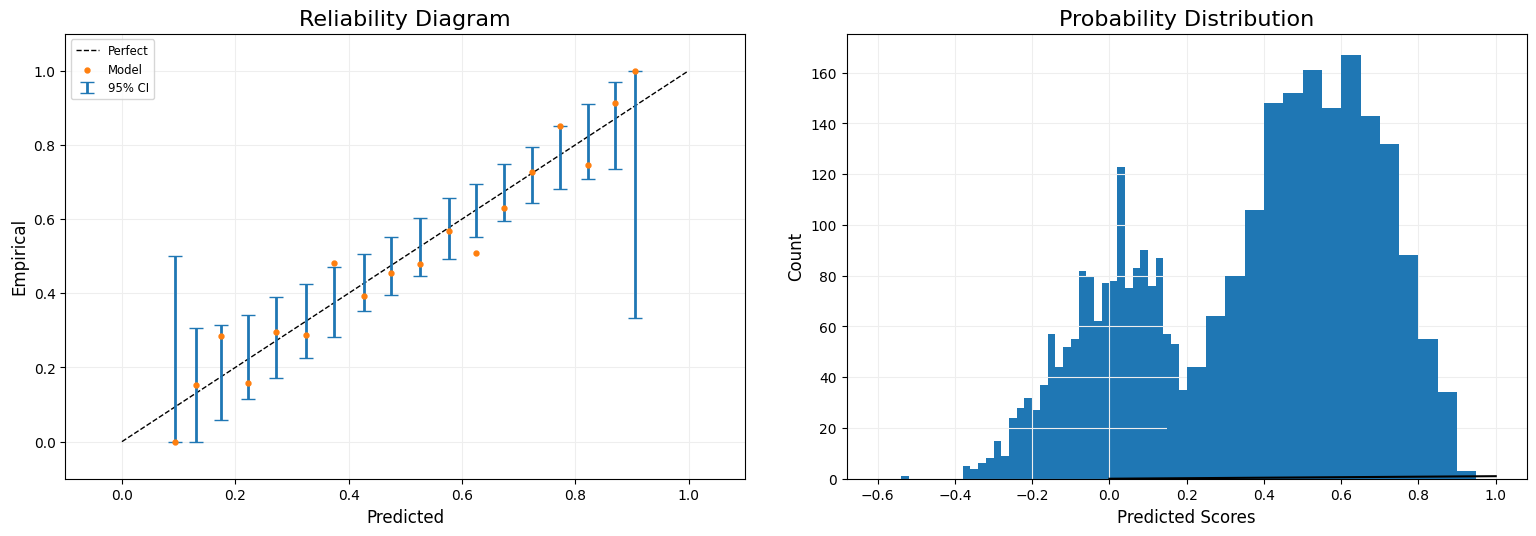

In [7]:
rd = mli.get_range_dict(trainX)
plot_pts = testX.sample(3, random_state=42)
mli.ice_plot(lgbm1, plot_pts, 'woba_pitch_away', mli.get_range_dict(trainX), plots_per_row=2)
#print(testX.columns[832])
plt.figure(figsize=(16,6))
mli.plot_reliability_diagram(testY, preds_lgbm, show_histogram=True)
plt.scatter(oddsDf.combinedOdds, preds_lgbm, marker='.', alpha=.1)
plt.plot([0,1],[0,1], color='k')
test_disc = preds_lgbm - oddsDf.combinedOdds
plt.hist(test_disc, bins=np.linspace(-.6,.6,61))